In [2]:
#Author: Shaan Mathur (primary) and Adrian Alvarez (secondary)

"""
THE FOLLOWING IS A NOTEBOOK OF OUR FINAL DEVELOPMENT AND SUMMARIZER AND BEST 
DEMONSTRATION OF WHAT OUR WORK CONCLUDED IN BECAUSE Project.ipynb IS A FULL START TO FINISH 
PIPELINE FOR EXPIREMENT TWO AND BEST MATCHES THE GOAL WE SET FROM THE OUTSET OF THE PROJECT 
OF REAL SUMMARIES BASED ON HIGH IMPACT STUDENT REVIEWS. 
IT STARTS FROM TRAINING THEN GOES INTO SUMMARIZATION CREATION AND END IN EVALUATION!

ALSO THIS NOTEBOOK COULD BE RUN SIMPLY BY ADDING AN API KEY BELOW AND RUNS VERY FAST
IN OUR EXPERIENCE WHEREAS THE OTHER NOTEBOOK MAY NEEDS SOME TWEAKS AS IT WAS MADE FOR
GOOGLE COLAB AND IS SLOWER!!!!!!!!
*AS LONG AS THE FULL REPO WAS CLONED CORRECTLY OF COURSE!
"""

"""
NOTEBOOK PURPOSE:

The pipeline begins by loading and cleaning the RateMyProfessor dataset and training
and testing two further fine tuned Bag of Words and TFIDF logistic regression models.

We pull top 20 positive and negative words from our logistic regression tf-idf model 
because eventhough Bag of Words had more accuracy the words were less meaningful which
is to be expected with Bag pof Words.

Then, since this is more of a last minute development we pick 20 
professors with 20 reviews.

For each review we multiply the absolute value of the sentiment score by our 
own calculated “worthwhile” score which gives a number based on the length 
of the review, and a number prioritizing good grades that left bad reviews or
bad grades that left good reviews. Normalization and weighting is used here to
make sure this worthwhileness score is used meaningfully.

We then pick the top 4 reviews that have the highest resulting product score 
so these are the 4 most worthwhile.

These four reviews are simply appended to each other as 1 large review and 
the llm is prompted to summarize these three highest impact reviews into 
one summary and we provide our top 20 pos/neg again and tell it that if it sees 
those words or very close synonyms to ensure the summary carries forward those terms.

Then we re-run our model on both the collection of the four reviews provided 
to the llm and get its sentiment score and also run it on our summary to get 
its sentiment score and analyze how close together these are. This shows if 
the model is hallucinating and/or if it is successfully carrying forward what
matters in its summary. AND MORE EVAL TOO!!!!!!!!!!
"""

'\nNOTEBOOK PURPOSE:\n\nThe pipeline begins by loading and cleaning the RateMyProfessor dataset and training\nand testing two further fine tuned Bag of Words and TFIDF logistic regression models.\n\nWe pull top 20 positive and negative words from our logistic regression tf-idf model \nbecause eventhough Bag of Words had more accuracy the words were less meaningful which\nis to be expected with Bag pof Words.\n\nThen, since this is more of a last minute development we pick 20 \nprofessors with 20 reviews.\n\nFor each review we multiply the absolute value of the sentiment score by our \nown calculated “worthwhile” score which gives a number based on the length \nof the review, and a number prioritizing good grades that left bad reviews or\nbad grades that left good reviews. Normalization and weighting is used here to\nmake sure this worthwhileness score is used meaningfully.\n\nWe then pick the top 4 reviews that have the highest resulting product score \nso these are the 4 most worthwhi

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

"""
"""

'\n'

In [4]:

data_path = './RateMyProfessorData.csv'
df = pd.read_csv(data_path)
display(df.head())


,professor_name,school_name,department_name,year_since_first_review,star_rating,take_again,diff_index,tag_professor,num_student,post_date,...,lots_of_homework,accessible_outside_class,lecture_heavy,extra_credit,graded_by_few_things,group_projects,test_heavy,so_many_papers,beware_of_pop_quizzes,IsCourseOnline
0,Kathy Brooks,Centralia College,Computer Science department,2.0,5.0,NaN,3.0,NaN,3.0,09/28/2005,...,0,0,0,0,0,0,0,0,0,0
1,Kathy Brooks,Centralia College,Computer Science department,2.0,5.0,NaN,3.0,NaN,3.0,09/27/2005,...,0,0,0,0,0,0,0,0,0,0
2,Kathy Brooks,Centralia College,Computer Science department,2.0,5.0,NaN,3.0,NaN,3.0,09/16/2003,...,0,0,0,0,0,0,0,0,0,0
3,John Bland,Kishwaukee College,Psychology department,1.0,5.0,NaN,2.0,NaN,2.0,07/12/2005,...,0,0,0,0,0,0,0,0,0,0
4,John Bland,Kishwaukee College,Psychology department,1.0,5.0,NaN,2.0,NaN,2.0,03/29/2004,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#CLEANING DATA SET
col_one = "comments"
col_two = "student_star"

df_clean = df.copy()

df_clean = df_clean.dropna(subset=[col_one, col_two])

df_clean[col_one] = (
    df_clean[col_one]
    .astype(str)
    .str.strip()
)

df_clean = df_clean[df_clean[col_one].str.len() >= 12].copy()

print("Rows BEFORE cleaning:", len(df))
print("Rows AFTER cleaning:", len(df_clean))
df_clean[[col_one, col_two]].head()

Rows BEFORE cleaning: 19997
Rows AFTER cleaning: 18757


,comments,student_star
0,AWESOME teacher,5.0
2,"Very good teacher, good sense of humor. Very s...",5.0
4,John made class fun & interesting.He was an aw...,5.0
5,She is probably one of the best teachers I hav...,5.0
6,"Wonderful, wonderful!! Highly recommened, I\'m...",5.0


In [6]:
#ADDING LABELS
df_clean["rating_per_review"] = np.where(df_clean["student_star"] >= 3.0, "positive", 
                                         np.where(df_clean["student_star"] <= 2.5, "negative", "neutral"))
print(df_clean["rating_per_review"].value_counts())

rating_per_review
positive    13557
negative     5200
Name: count, dtype: int64


In [7]:
#SETUP TRAIN
train_df = df_clean[df_clean["rating_per_review"].isin(["positive", "negative"])]

X = train_df["comments"]
y = train_df["rating_per_review"]


X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size= 0.3, random_state = 42, stratify = y)

In [8]:
#tf

tfidf = TfidfVectorizer(stop_words= "english", ngram_range = (1,2), min_df = 2, max_features = 50000)
Lr = LogisticRegression(max_iter = 2000, class_weight = "balanced")

model = Pipeline([
    ("tfidf", tfidf),
    ("lr", Lr)
])

model.fit(X_train, y_train)

#bag of

bow = CountVectorizer(stop_words= "english", ngram_range=(1,2), min_df=2, max_features=50000)
lr_bow = LogisticRegression(max_iter=2000, class_weight="balanced")

model_bow = Pipeline([
    ("bow", bow),
    ("lr", lr_bow)
])

model_bow.fit(X_train, y_train)

,steps,"[('bow', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [9]:
#PREDICT AND DISPALY
y_pred = model.predict(X_test)

y_pred_bow = model_bow.predict(X_test)

print("Accuracy of TF-IDF:", accuracy_score(y_test, y_pred), "vs Accuracy of BoW:", accuracy_score(y_test, y_pred_bow))
print("\n(TF-IDF + LR)\n", classification_report(y_test, y_pred), "\n (BOW + LR)\n", classification_report(y_test, y_pred_bow))

Accuracy of TF-IDF: 0.8546552949538024 vs Accuracy of BoW: 0.8539445628997868

(TF-IDF + LR)
               precision    recall  f1-score   support

    negative       0.70      0.83      0.76      1560
    positive       0.93      0.86      0.90      4068

    accuracy                           0.85      5628
   macro avg       0.82      0.85      0.83      5628
weighted avg       0.87      0.85      0.86      5628
 
 (BOW + LR)
               precision    recall  f1-score   support

    negative       0.72      0.78      0.75      1560
    positive       0.91      0.88      0.90      4068

    accuracy                           0.85      5628
   macro avg       0.82      0.83      0.82      5628
weighted avg       0.86      0.85      0.86      5628



In [13]:

#SHOWCASE WORDS

words_tfidf = model.named_steps["tfidf"].get_feature_names_out()
score_tfidf = model.named_steps["lr"].coef_[0]

tfidf_importance = pd.DataFrame({'word': words_tfidf, 'score': score_tfidf})
tfidf_importance = tfidf_importance.sort_values(by='score', ascending=False)

words_bow = model_bow.named_steps["bow"].get_feature_names_out()
score_bow = model_bow.named_steps["lr"].coef_[0]

bow_importance = pd.DataFrame({'word': words_bow, 'score': score_bow})
bow_importance = bow_importance.sort_values(by='score', ascending=False)

print("--- TOP 20 POSITIVE WORDS ---")
print("TF-IDF:")
display(tfidf_importance.head(20))
print("\nBag of Words:")
display(bow_importance.head(20))

print("\n--- TOP 20 NEGATIVE WORDS ---")
print("TF-IDF:")
display(tfidf_importance.tail(20))
print("\nBag of Words:")
display(bow_importance.tail(20))

print("Eventhough the bag of words model has a slightly higher accuracy, we see the tfidf words as more meaningful" \
"so we will carry those forward")
top20pos = tfidf_importance["word"].head(20).tolist()
top20neg = tfidf_importance["word"].tail(20).tolist()
print(top20pos)
print(top20neg)

--- TOP 20 POSITIVE WORDS ---
TF-IDF:


,word,score
8946,great,7.446910
1587,best,6.213389
1319,awesome,4.782888
5970,easy,4.429434
13272,love,3.661042
652,amazing,3.292590
7194,fair,3.204412
6859,excellent,3.094964
13320,loved,3.067663
7955,funny,3.041803



Bag of Words:


,word,score
1319,awesome,2.675132
1587,best,2.527346
8946,great,2.156584
6859,excellent,2.100404
13272,love,1.901279
23557,wonderful,1.821245
13320,loved,1.750717
4124,cool,1.684166
652,amazing,1.629629
7346,favorite,1.518175



--- TOP 20 NEGATIVE WORDS ---
TF-IDF:


,word,score
1312,away,-2.185738
18456,saying,-2.200159
21160,terrible,-2.292934
11995,late,-2.361302
20541,talks,-2.617899
1369,awful,-2.708648
23847,worst teacher,-2.731198
23981,wrong,-2.750701
22653,unhelpful,-2.929132
3995,confused,-2.997492



Bag of Words:


,word,score
10948,interesting assignments,-1.513911
10776,insane,-1.514990
18300,rude,-1.539769
1369,awful,-1.560483
19227,spaced,-1.568309
4002,confusing,-1.575650
21610,things easy,-1.588116
10555,idiot,-1.617347
22470,unclear,-1.625031
14288,moodle,-1.627329


Eventhough the bag of words model has a slightly higher accuracy, we see the tfidf words as more meaningfulso we will carry those forward
['great', 'best', 'awesome', 'easy', 'love', 'amazing', 'fair', 'excellent', 'loved', 'funny', 'great teacher', 'really', 'wonderful', 'interesting', 'cool', 'fun', 'good teacher', 'nice', 'lot', 'willing']
['away', 'saying', 'terrible', 'late', 'talks', 'awful', 'worst teacher', 'wrong', 'unhelpful', 'confused', 'confusing', 'boring', 'unclear', 'hard understand', 'rude', 'teach', 'doesn', 'avoid', 'horrible', 'worst']


In [14]:
#PIPE DATA FOR FUTURE STEPS AND ADDING SCORES
classes = list(model.named_steps["lr"].classes_)
pos_idx = classes.index("positive")

score_review = model.predict_proba(df_clean["comments"])[:, pos_idx]

df_clean["sentiment_score"] = 2 * score_review - 1
df_clean[["professor_name", "comments", "word_comment", "student_star", "grades", "rating_per_review","sentiment_score"]].head()

,professor_name,comments,word_comment,student_star,grades,rating_per_review,sentiment_score
0,Kathy Brooks,AWESOME teacher,2.0,5.0,NaN,positive,0.973368
2,Kathy Brooks,"Very good teacher, good sense of humor. Very s...",9.0,5.0,NaN,positive,0.861694
4,John Bland,John made class fun & interesting.He was an aw...,40.0,5.0,NaN,positive,0.721309
5,Sparkle Raymond,She is probably one of the best teachers I hav...,53.0,5.0,NaN,positive,0.888669
6,Sparkle Raymond,"Wonderful, wonderful!! Highly recommened, I\'m...",22.0,5.0,NaN,positive,0.806452


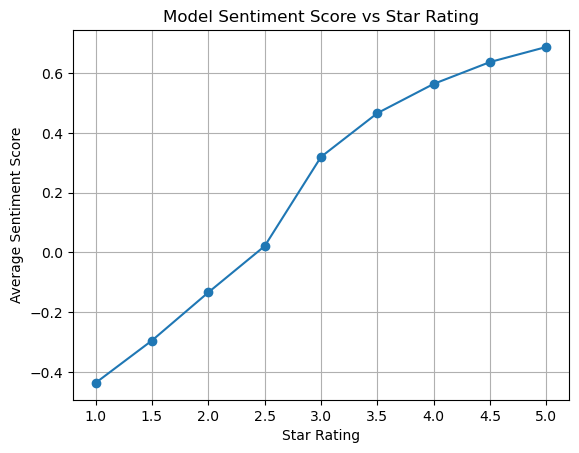

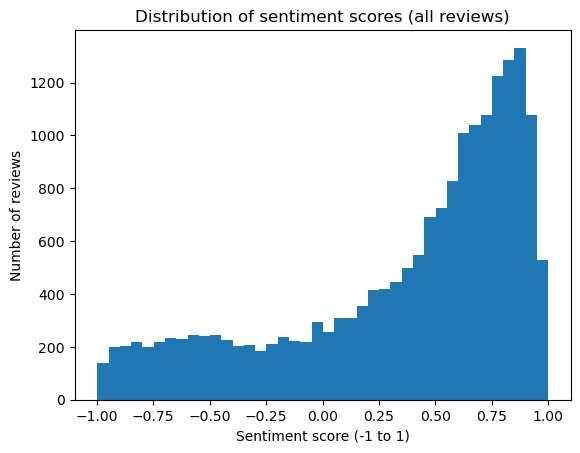

In [15]:
#PLOTS TO VERIFY GOOD JOB DONE

avg_scores = df_clean.groupby("student_star")["sentiment_score"].mean()

plt.figure()
avg_scores.plot(marker="o")
plt.xlabel("Star Rating")
plt.ylabel("Average Sentiment Score")
plt.title("Model Sentiment Score vs Star Rating")
plt.grid(True)
plt.show()

plt.hist(df_clean["sentiment_score"], bins=40)
plt.xlabel("Sentiment score (-1 to 1)")
plt.ylabel("Number of reviews")
plt.title("Distribution of sentiment scores (all reviews)")
plt.show()

#NICE IT SEEMED TO BE GOOD BASED ON PLOTZ!


In [16]:
#THIS IS A LOT SO COMMENTS WILL BE SPLIT

print(top20pos)
print(top20neg)

#PICKING 20 PROFESSORS WHO EACH HAVE 20 (MAX) REVIEWS
prof_df = pd.read_csv(data_path, usecols=["professor_name"])

prof_counts = prof_df["professor_name"].value_counts().reset_index()
prof_counts.columns = ["professor_name", "num_reviews"]
prof_counts = prof_counts.sort_values("num_reviews", ascending=False)

#TWO PROFESSORS WITH DUPE NAMES SO THATS WHY SLICE IS WEIRD
top20_profs = prof_counts.iloc[2:22]
display(top20_profs)

#ABS VAL OF SENT SCORE GIVES PURE STRENGTH
#LOG OF WORDS IS A BETTER SCALE 
#OBV COULD GO DEEP WITH THIS WORTHWHILE SCORE BUT WE ARE LIMITED IN KNOWLEDGE AND TIME
df_clean["sent_strength"] = np.abs(df_clean["sentiment_score"])
df_clean["length_score"] = np.log1p(df_clean["word_comment"])

#ABLE TO ALSO IMPLEMENT THAT INITIAL DREAM OF LIKE A TFIDF SLIDE SCALE FOR 
#REWARDING GOOD GRADE BAD REVIEW AND BAD GRADE GOOD REVIEW
#IGNORING NO GRADES MEANS THEY DONT GET THAT BOOST
#AND LIKE EXPLAINED HEAVILIY REWARDING THAT INVERSE
#SO WE NOW GOT PURE SENT STRENGTH, LOG WORD COUNT, GRADE SURPRISE
#NORMALIZE AND THEN WEIGHT AND SEND FORWARD!
grade_map = {
    "A+": 4.3, "A": 4.0, "A-": 3.7,
    "B+": 3.3, "B": 3.0, "B-": 2.7,
    "C+": 2.3, "C": 2.0, "C-": 1.7,
    "D+": 1.3, "D": 1.0, "D-": 0.7,
    "F": 0.0
}
df_clean["grades"] = df_clean["grades"].astype(str).str.strip().str.upper()
df_clean["grades"] = df_clean["grades"].replace({"": np.nan, "NAN": np.nan})
df_clean["grade_num"] = df_clean["grades"].map(grade_map)
df_clean["grade_scaled"] = df_clean["grade_num"] / 4.3
df_clean["grade_sentiment"] = 2 * df_clean["grade_scaled"] - 1

df_clean["grade_surprise"] = np.abs(
    df_clean["sentiment_score"] - df_clean["grade_sentiment"]
)
df_clean["grade_surprise"] = df_clean["grade_surprise"].fillna(0)

df_clean["sent_strength"] = df_clean["sent_strength"] / df_clean["sent_strength"].max()
df_clean["length_score"] = df_clean["length_score"] / df_clean["length_score"].max()
df_clean["grade_surprise"] = df_clean["grade_surprise"] / df_clean["grade_surprise"].max()

df_clean["worthwhileness"] = (
    0.5 * df_clean["sent_strength"] +
    0.2 * df_clean["length_score"] +
    0.3 * df_clean["grade_surprise"]
)

#THE FOLLOWING IS PANDAS WORK TO END WITH A TABLE THAT HAS
#EACH OF THOSE 20 PROFESSORS SIDE BY SIDE WITH THE CONCATENATION
#OF THEIR 4 MOST WORTHWHILE REVIEWS
df_clean["comments"] = df_clean["comments"].fillna("").astype(str)

selected_profs = top20_profs["professor_name"].tolist()

df_top20 = df_clean[df_clean["professor_name"].isin(selected_profs)].copy()

df_top20 = df_top20.sort_values(
    ["professor_name", "worthwhileness"],
    ascending=[True, False]
)

prof_review_table = (
    df_top20.groupby("professor_name")["comments"]
    .apply(lambda x: " \n\n ".join(x.head(4)))
    .reset_index()
)

prof_review_table.columns = ["professor_name", "top_4_worthwhile_reviews"]

prof_review_table["professor_name"] = pd.Categorical(
    prof_review_table["professor_name"],
    categories=selected_profs,
    ordered=True
)

prof_review_table = prof_review_table.sort_values("professor_name").reset_index(drop=True)

display(prof_review_table)

['great', 'best', 'awesome', 'easy', 'love', 'amazing', 'fair', 'excellent', 'loved', 'funny', 'great teacher', 'really', 'wonderful', 'interesting', 'cool', 'fun', 'good teacher', 'nice', 'lot', 'willing']
['away', 'saying', 'terrible', 'late', 'talks', 'awful', 'worst teacher', 'wrong', 'unhelpful', 'confused', 'confusing', 'boring', 'unclear', 'hard understand', 'rude', 'teach', 'doesn', 'avoid', 'horrible', 'worst']


,professor_name,num_reviews
412,Duane Griffin,20
405,Susan Larkin,20
406,Ken Sumner,20
407,Andrew Delamater,20
408,Peter Jurs,20
409,Thomas Cooke,20
410,Irv Englander,20
411,William Stoever,20
413,Michael Kwag,20
403,Geri Olson,20


,professor_name,top_4_worthwhile_reviews
0,Duane Griffin,this is the worst teacher I\'ve ever had in my...
1,Susan Larkin,Dr. Larkin is simply the best PED Prof. in PED...
2,Ken Sumner,He is by far the worst teacher Ive ever had in...
3,Andrew Delamater,I highly recommend him!His lectures were cryst...
4,Peter Jurs,"Can be dry at times, but a nice guy overall. ""..."
5,Thomas Cooke,Doesn\'t really care about the course. Asks te...
6,Irv Englander,this class is the worst IT class you can ever ...
7,William Stoever,Finally a professor who made me feel like I wa...
8,Michael Kwag,Kwag is a very knowledgable professor. His lec...
9,Geri Olson,"She\'s an interesting professor. Really nice, ..."


In [ ]:
#BUILD PROMPT AND ADD IT AS A NEW COLUMN 
def build_professor_prompt(professor_name, appended_reviews, top20pos, top20neg):
    return f"""
You are summarizing student reviews for a professor.

Professor name:
{professor_name}

Most worthwhile student reviews:
{appended_reviews}

Top positive sentiment words from the dataset:
{top20pos}

Top negative sentiment words from the dataset:
{top20neg}

Task:
Write a concise summary of the most impactful things a student should know about this professor.

Instructions:
- Base the summary on the review text above.
- Treat the positive and negative word lists as guidance for important sentiment-bearing traits.
- If the reviews clearly support a word or idea from those lists, carry that wording forward naturally into the summary.
- Do not include a keyword unless it is supported by the reviews.
- Prefer concrete repeated themes over vague praise or vague complaints.
- Focus especially on clarity, organization, helpfulness, fairness, workload, grading, exams, lecture quality, and overall classroom experience when mentioned.
- Preserve both positive and negative points when both are present.
- Do not invent details or overstate weak evidence.
- Write 4-6 sentences in a neutral, informative style.

Output:
Return only the final summary paragraph.
""".strip()

pos_words_text = ", ".join(map(str, top20pos))
neg_words_text = ", ".join(map(str, top20neg))

prof_review_table["llm_prompt"] = prof_review_table.apply(
    lambda row: build_professor_prompt(
        professor_name=row["professor_name"],
        appended_reviews=row["top_4_worthwhile_reviews"],
        top20pos=pos_words_text,
        top20neg=neg_words_text
    ),
    axis=1
)

display(prof_review_table[["professor_name", "llm_prompt"]].head())

,professor_name,llm_prompt
0,Duane Griffin,You are summarizing student reviews for a prof...
1,Susan Larkin,You are summarizing student reviews for a prof...
2,Ken Sumner,You are summarizing student reviews for a prof...
3,Andrew Delamater,You are summarizing student reviews for a prof...
4,Peter Jurs,You are summarizing student reviews for a prof...


In [ ]:
#RUNNING SUMMARY GENERATION AND ATTACHING AS NEW COLUMN
%pip install openai
from openai import OpenAI
import pandas as pd
import time

client = OpenAI(api_key="")

def summarize_professor(prompt):
    try:
        response = client.responses.create(
            model="gpt-4.1-mini",
            instructions="You are a careful academic review summarizer. Use only evidence supported by the provided reviews.",
            input=prompt,
            temperature=0.2,
            max_output_tokens=250
        )
        return response.output_text.strip()
    except Exception as e:
        return f"ERROR: {e}"

prof_review_table["professor_summary"] = prof_review_table["llm_prompt"].apply(summarize_professor)

prof_review_table.to_csv("professor_summaries.csv", index=False)

display(prof_review_table[["professor_name", "professor_summary"]].head(20))

Note: you may need to restart the kernel to use updated packages.


,professor_name,professor_summary
0,Duane Griffin,Professor Duane Griffin is described as a quir...
1,Susan Larkin,Professor Susan Larkin is highly regarded for ...
2,Ken Sumner,Students have reported widely differing experi...
3,Andrew Delamater,Professor Andrew Delamater is known for delive...
4,Peter Jurs,Professor Peter Jurs is generally regarded as ...
5,Thomas Cooke,Professor Thomas Cooke’s classes are generally...
6,Irv Englander,Professor Irv Englander is an experienced and ...
7,William Stoever,Professor William Stoever is highly regarded f...
8,Michael Kwag,Professor Michael Kwag is knowledgeable and de...
9,Geri Olson,Professor Geri Olson offers an interesting and...


In [ ]:
#EVALUATION AND ANALYSIS
#ADDING A MEAN OF THE SENTIMENTS OF EACH OF THE FOUR REVIEWS INDIVIDUALLY
#A CHUNK SENTIMENT OF THE 4 REVEIEWS TOGETHER
#A SENTIMENT FOR THE FINAL SUMMARY
prof_review_table = pd.read_csv("professor_summaries.csv")

prof_review_table["top_4_worthwhile_reviews"] = prof_review_table["top_4_worthwhile_reviews"].fillna("").astype(str)
prof_review_table["professor_summary"] = prof_review_table["professor_summary"].fillna("").astype(str)

mean_sent = (
    df_clean.groupby("professor_name")["sentiment_score"]
    .mean()
    .reset_index(name="mean_review_sentiment")
)

prof_review_table = prof_review_table.merge(mean_sent, on="professor_name", how="left")

classes = list(model.named_steps["lr"].classes_)
pos_idx = classes.index("positive")

chunk_prob = model.predict_proba(prof_review_table["top_4_worthwhile_reviews"])[:, pos_idx]
prof_review_table["chunk_sentiment_score"] = 2 * chunk_prob - 1

summary_prob = model.predict_proba(prof_review_table["professor_summary"])[:, pos_idx]
prof_review_table["summary_sentiment_score"] = 2 * summary_prob - 1

prof_review_table["sentiment_difference"] = (
    prof_review_table["summary_sentiment_score"] - prof_review_table["chunk_sentiment_score"]
)

prof_review_table["abs_sentiment_difference"] = prof_review_table["sentiment_difference"].abs()

display(
    prof_review_table[[
        "professor_name",
        "mean_review_sentiment",
        "chunk_sentiment_score",
        "summary_sentiment_score",
        "sentiment_difference",
        "abs_sentiment_difference"
    ]]
)

,professor_name,mean_review_sentiment,chunk_sentiment_score,summary_sentiment_score,sentiment_difference,abs_sentiment_difference
0,Duane Griffin,0.117679,0.645997,0.546989,-0.099009,0.099009
1,Susan Larkin,0.332589,0.979784,0.888595,-0.091189,0.091189
2,Ken Sumner,-0.115769,-0.882239,0.326258,1.208498,1.208498
3,Andrew Delamater,0.097829,0.809863,0.526365,-0.283497,0.283497
4,Peter Jurs,0.274863,0.678746,0.757488,0.078743,0.078743
5,Thomas Cooke,0.432968,0.778357,0.281604,-0.496752,0.496752
6,Irv Englander,0.211474,0.725851,0.369931,-0.355920,0.355920
7,William Stoever,0.393691,0.992478,0.859883,-0.132595,0.132595
8,Michael Kwag,0.250507,-0.092157,0.068616,0.160773,0.160773
9,Geri Olson,0.375328,0.762297,0.226622,-0.535675,0.535675
